# Capital Asset Pricing Model

In [ ]:
from datetime import date, timedelta
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
from util import util_yahoo_finance as uyf

## From Two-Fund Separation to CAPM

With a risk-free asset, every investor holds the *same* tangency portfolio $w_T$, differing only in their split between $w_T$ and cash. CAPM is what happens when you add one assumption and impose market clearing.

**The added assumption — homogeneous expectations.** Everyone uses the same inputs $\mu$ and $\Sigma$. Same beliefs about returns and risk. (Strong, unrealistic, but it's what makes the model tractable — and you relax it in APT.)

**The market-clearing step.** If everyone has the same $\mu$,  $\Sigma$, then everyone computes the *same* tangency portfolio $w_T$. Now ask: who holds what, in aggregate? Every share of every asset must be held by *someone* — markets clear. If every investor holds risky assets in the proportions $w_T$, then the aggregate of all risky holdings is also in those proportions. But the aggregate of all risky holdings, by definition, *is* the market portfolio $w_{mkt}$ — every asset weighted by its market cap.

Therefore:

$$
w_T = w_{mkt}
$$

The tangency portfolio **is** the market portfolio. This is the single key deduction of CAPM. It's not assumed — it falls out of "everyone optimizes identically + markets must clear." The thing everyone optimally holds must be the thing that exists in aggregate.

Identical beliefs → everyone wants the same risky proportions → but every share must be held → prices adjust until the commonly-desired portfolio equals the market portfolio → $w_T = w_{mkt}$.

Recall the tangency portfolio's closed form:

$$
w_T = \frac{\Sigma^{-1}(\mu - r_f\mathbf{1})}{\mathbf{1}^T\Sigma^{-1}(\mu - r_f\mathbf{1})}
$$

Set $w_T = w_{mkt}$ and rearrange for the excess returns $\mu - r_f\mathbf{1}$:

$$
\boxed {\mu - r_f\mathbf{1} = \delta\,\Sigma\, w_{mkt}}
$$

where $\delta$ absorbs the normalizing scalar (it's the market's risk aversion). **That is exactly the reverse-optimization formula $\Pi = \delta\Sigma w_{mkt}$ from Black-Litterman.** Black-Litterman's prior isn't an arbitrary choice — it's the unique set of expected returns consistent with the market being the tangency portfolio.

## Beta and the Security Market Line

We just derived the equilibrium condition for the *whole* vector of returns: $\mu - r_f\mathbf{1} = \delta\Sigma w_{mkt}$. Now we extract what it says about a *single* asset, which is the form everyone knows as CAPM.

Look at one row of the vector equation. Row $i$ of $\Sigma w_{mkt}$ is $(\Sigma w_{mkt})_i = \sum_j \Sigma_{ij}\, w_{mkt,j} = \text{Cov}(r_i,\ \sum_j w_{mkt,j} r_j) = \text{Cov}(r_i, r_m)$.

That's the key recognition: the $i$-th entry of $\Sigma w_{mkt}$ is the **covariance of asset $i$ with the market return** $r_m = w_{mkt}^T r$. So row $i$ of the equilibrium condition reads:

$$
\mu_i - r_f = \delta\,\text{Cov}(r_i, r_m)
$$

**Pin down $\delta$ using the market itself.** Apply this same relation to the market portfolio as a whole — its covariance with itself is its variance $\sigma_m^2$:

$$
\mu_m - r_f = \delta\,\text{Cov}(r_m, r_m) = \delta\,\sigma_m^2 \implies \delta = \frac{\mu_m - r_f}{\sigma_m^2}
$$

There's the risk-aversion scalar again, now confirmed as market excess return over market variance — exactly the value we asserted on faith for Black-Litterman.

**Substitute $\delta$ back:**

$$
\mu_i - r_f = \frac{\text{Cov}(r_i, r_m)}{\sigma_m^2}(\mu_m - r_f)
$$

Define **beta** as that covariance ratio:

$$
\beta_i = \frac{\text{Cov}(r_i, r_m)}{\sigma_m^2}
$$

and you have the **CAPM equation**:

$$
\boxed{\mu_i - r_f = \beta_i(\mu_m - r_f)}
$$

An asset's expected excess return is proportional to its beta, and the constant of proportionality is the market's excess return (the "market risk premium"). Plotting $\mu_i$ against $\beta_i$ gives a straight line — the **Security Market Line** — with intercept $r_f$ and slope $(\mu_m - r_f)$.

Risk-free rate       : 3.00%
Market exp. return   : 0.1341
Market volatility    : 0.1272

Security          w_M      μ_i      β_i     SML μ
Tech           0.2131   0.1500   1.1529    0.1500
Finance        0.3105   0.1200   0.8647    0.1200
Healthcare     0.2290   0.1000   0.6725    0.1000
Energy         0.0257   0.0800   0.4804    0.0800
Consumer       0.2217   0.1800   1.4412    0.1800


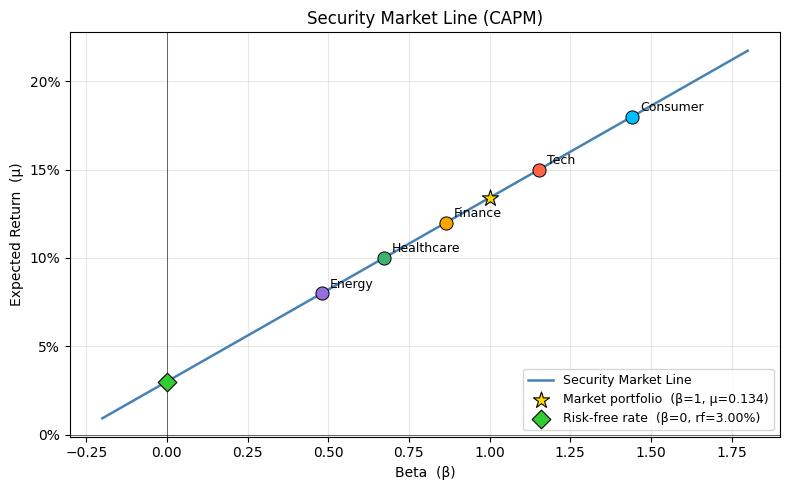

In [ ]:
# ── Security Market Line (CAPM) — fabricated data, illustration only ──────────
# 5 securities: Tech, Finance, Healthcare, Energy, Consumer

names = ["Tech", "Finance", "Healthcare", "Energy", "Consumer"]

mu = np.array([0.15, 0.12, 0.10, 0.08, 0.18])   # expected returns

Sigma = np.array([                                 # covariance matrix
    [0.0400, 0.0120, 0.0080, 0.0060, 0.0200],
    [0.0120, 0.0225, 0.0090, 0.0070, 0.0100],
    [0.0080, 0.0090, 0.0196, 0.0050, 0.0080],
    [0.0060, 0.0070, 0.0050, 0.0289, 0.0110],
    [0.0200, 0.0100, 0.0080, 0.0110, 0.0625],
])

rf = 0.03                                          # risk-free rate

# ── Market (tangency) portfolio: w_M ∝ Σ⁻¹(μ - rf·1) ────────────────────────
z   = np.linalg.solve(Sigma, mu - rf)             # Σ⁻¹(μ - rf·1)
w_M = z / z.sum()                                 # normalise to sum to 1

mu_M  = w_M @ mu                                  # market expected return
var_M = w_M @ Sigma @ w_M                         # market variance

# ── Beta: β_i = Cov(r_i, r_M) / Var(r_M) = (Σ w_M)_i / σ²_M ────────────────
beta = (Sigma @ w_M) / var_M

print(f"Risk-free rate       : {rf:.2%}")
print(f"Market exp. return   : {mu_M:.4f}")
print(f"Market volatility    : {var_M**0.5:.4f}")
print()
print(f"{'Security':<12} {'w_M':>8} {'μ_i':>8} {'β_i':>8}  {'SML μ':>8}")
for i, name in enumerate(names):
    sml_mu = rf + beta[i] * (mu_M - rf)
    print(f"{name:<12} {w_M[i]:>8.4f} {mu[i]:>8.4f} {beta[i]:>8.4f}  {sml_mu:>8.4f}")

# ── Plot: μ_i vs β_i with SML ─────────────────────────────────────────────────
beta_grid = np.linspace(-0.2, 1.8, 300)
sml       = rf + beta_grid * (mu_M - rf)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(beta_grid, sml, color="steelblue", lw=1.8, label="Security Market Line")

colors = ["tomato", "orange", "mediumseagreen", "mediumpurple", "deepskyblue"]
for i, name in enumerate(names):
    ax.scatter(beta[i], mu[i], s=90, color=colors[i], edgecolors="k", lw=0.7, zorder=5)
    ax.annotate(name, (beta[i], mu[i]), textcoords="offset points",
                xytext=(6, 4), fontsize=9)

# Market portfolio sits at β = 1 by construction
ax.scatter(1.0, mu_M, s=150, marker="*", color="gold", edgecolors="k",
           lw=0.8, zorder=6, label=f"Market portfolio  (β=1, μ={mu_M:.3f})")

# Risk-free rate sits at β = 0
ax.scatter(0.0, rf, s=90, marker="D", color="limegreen", edgecolors="k",
           lw=0.8, zorder=6, label=f"Risk-free rate  (β=0, rf={rf:.2%})")

ax.axhline(0, color="k", lw=0.4)
ax.axvline(0, color="k", lw=0.4)
ax.set_xlabel("Beta  (β)")
ax.set_ylabel("Expected Return  (μ)")
ax.set_title("Security Market Line (CAPM)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The conceptual payload — only systematic risk is priced. Beta measures how much an asset co-moves with the market. CAPM says you're compensated *only* for that co-movement, not for the asset's total risk. Why? Idiosyncratic risk (the part of an asset's variance uncorrelated with the market) can be diversified away for free by holding the market portfolio, so the market doesn't pay you to bear it. Only the undiversifiable, market-correlated piece earns a premium. An asset with high total volatility but zero beta earns only $r_f$ — its volatility is all diversifiable, hence unpriced.

Beta is exactly the regression coefficient of $r_i$ on $r_m$ — connecting to OLS and to the single-index covariance model $\sigma_{ij} = \beta_i\beta_j\sigma_m^2$.